In [33]:
import sys
import os

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [34]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from utils.integral import grid
from Models.clustering import EMIFCF, IFCF
import torch

In [35]:
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
import numpy as np

# ===== Load MNIST =====
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root="../dataset/data", train=True, download=True, transform=transform)

# ===== Cấu hình riêng cho từng label =====
labels_to_take = {0: 50, 5: 100}   # label: số ảnh cần lấy

pdf_list = []
selected_labels = []
counts = {lbl: 0 for lbl in labels_to_take}

for img, label in train_dataset:
	if label in labels_to_take and counts[label] < labels_to_take[label]:
		arr = (img.squeeze(0).numpy())   # (28,28), giá trị gốc [0..255]

		weights = arr 
		pdf = weights / (weights.sum() + 1e-12)

		pdf_list.append(pdf)
		selected_labels.append(label)
		counts[label] += 1

    # nếu đủ số lượng cho tất cả label thì dừng
	if all(counts[lbl] >= labels_to_take[lbl] for lbl in labels_to_take):
		break

F_data = np.array(pdf_list)       # (20, 28, 28)
selected_labels = np.array(selected_labels)



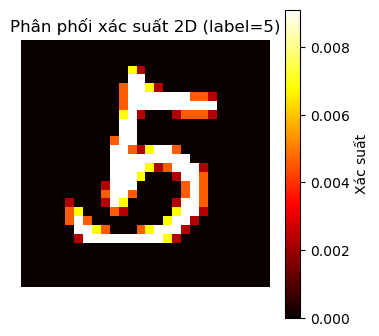

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# ==== Vẽ hình ====
plt.figure(figsize=(4,4))
plt.imshow(pdf, cmap="hot", interpolation="nearest")
plt.colorbar(label="Xác suất")
plt.title(f"Phân phối xác suất 2D (label={label})")
plt.axis("off")
plt.show()


In [37]:
bandwidth = 1.0
nx, ny = 28, 28
x = np.arange(nx)
y = np.arange(ny)
xx, yy = np.meshgrid(x, y)
grid = np.stack([xx.ravel(), yy.ravel()], axis=1)  # (784, 2)

In [38]:
# ví dụ tạo model
model = IFCF.Model(
    grid_x=grid,
    num_clusters=len(labels_to_take),   # số cụm mong muốn
    fuzziness=2,
    max_iterations=200,
    tolerance=1e-6,
    distance_metric="H",  # hoặc "L2", "W2"
    bandwidth=bandwidth,
 	#   init = 'k',
    verbose=True,
    Dim=2
)

# chạy clustering
model.fit(F_data)
U,centroids,_ = model.get_results()

[IFCM] it=001 | dU=4.484e+00 | dTheta=1.115e-01 | ΔJ=inf | J=7.808165e+01 | f=[0.47296988 0.52703012]
[IFCM] it=002 | dU=1.365e+00 | dTheta=7.660e-03 | ΔJ=3.896e+01 | J=3.911667e+01 | f=[0.45740874 0.54259126]
[IFCM] it=003 | dU=4.851e-01 | dTheta=3.808e-03 | ΔJ=3.930e-01 | J=3.872363e+01 | f=[0.44346011 0.55653989]
[IFCM] it=004 | dU=2.844e-01 | dTheta=2.336e-03 | ΔJ=1.095e-01 | J=3.861414e+01 | f=[0.43614037 0.56385963]
[IFCM] it=005 | dU=1.850e-01 | dTheta=1.531e-03 | ΔJ=4.419e-02 | J=3.856995e+01 | f=[0.43174518 0.56825482]
[IFCM] it=006 | dU=1.253e-01 | dTheta=1.035e-03 | ΔJ=1.987e-02 | J=3.855008e+01 | f=[0.428981 0.571019]
[IFCM] it=007 | dU=8.671e-02 | dTheta=7.121e-04 | ΔJ=9.400e-03 | J=3.854068e+01 | f=[0.42719297 0.57280703]
[IFCM] it=008 | dU=6.067e-02 | dTheta=4.948e-04 | ΔJ=4.569e-03 | J=3.853611e+01 | f=[0.42601257 0.57398743]
[IFCM] it=009 | dU=4.270e-02 | dTheta=3.459e-04 | ΔJ=2.253e-03 | J=3.853386e+01 | f=[0.42522098 0.57477902]
[IFCM] it=010 | dU=3.014e-02 | dTheta=

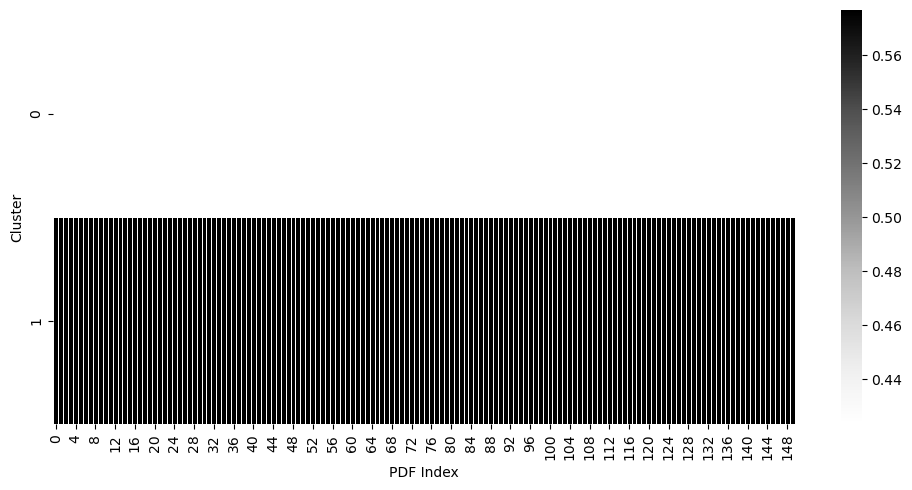

In [39]:
# plotHeatmap_U(U)
plt.figure(figsize=(10, 5))

sns.heatmap(
	U,
	cmap='Greys',
	cbar=True,
	linewidths=0.5,
   
    
)

plt.ylabel('Cluster')
plt.xlabel('PDF Index')
plt.tight_layout()
# plt.savefig('KCF_U.pdf', bbox_inches="tight")

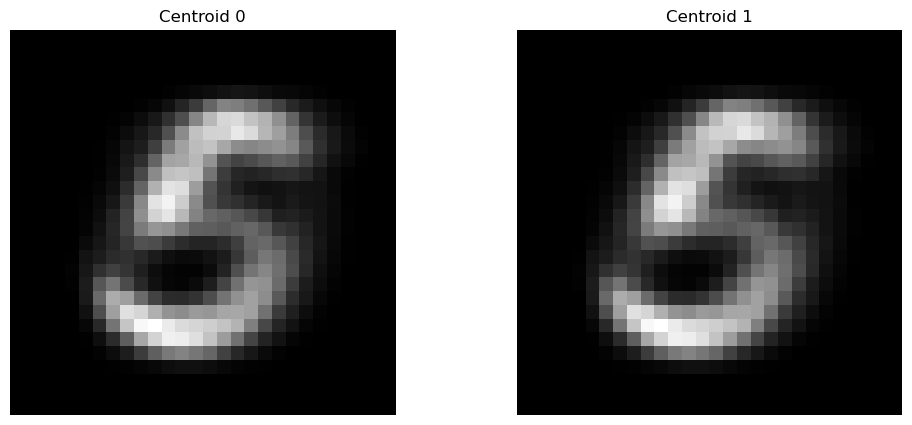

In [40]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for i in range(len(centroids)):
	plt.subplot(1, len(centroids), i + 1)
	plt.imshow(centroids[i].reshape(28, 28), cmap='gray')
	plt.axis('off')
	plt.title(f'Centroid {i}')